In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q monai==1.6.0 nibabel wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.6 MB/s eta 0:00:00


In [3]:
import os
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

import monai
from monai.data import Dataset
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.transforms import (
    LoadImaged,
    EnsureChannelFirstd,
    ConcatItemsd,
    NormalizeIntensityd,
    AsDiscrete,
    Compose,
    MapTransform,
)

print(f"MONAI version: {monai.__version__}")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

MONAI version: 1.6.0
Using device: cuda
GPU: Tesla T4


In [4]:
BASE_DIR = "/content/drive/MyDrive/brain-tumor-segmentation"

PATHS = {
    "configs": os.path.join(BASE_DIR, "configs"),
    "models": os.path.join(BASE_DIR, "models", "baseline"),
    "figures": os.path.join(BASE_DIR, "results", "figures"),
    "metrics": os.path.join(BASE_DIR, "results", "metrics"),
    "archive": os.path.join(BASE_DIR, "archive"),
}

for key in ["configs", "models", "figures", "metrics"]:
    os.makedirs(PATHS[key], exist_ok=True)

print("Paths configured:")
for name, path in PATHS.items():
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"  [{status}] {name:10s} -> {path}")

Paths configured:
  [OK] configs    -> /content/drive/MyDrive/brain-tumor-segmentation/configs
  [OK] models     -> /content/drive/MyDrive/brain-tumor-segmentation/models/baseline
  [OK] figures    -> /content/drive/MyDrive/brain-tumor-segmentation/results/figures
  [OK] metrics    -> /content/drive/MyDrive/brain-tumor-segmentation/results/metrics
  [OK] archive    -> /content/drive/MyDrive/brain-tumor-segmentation/archive


In [5]:
BEST_MODEL_PATH = os.path.join(
    PATHS["models"],
    "best_model.pth"
)

print("Best model:")
print(BEST_MODEL_PATH)

if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(
        f"Best model not found:\n{BEST_MODEL_PATH}"
    )

print("\nCheckpoint found.")
print(
    f"File size: "
    f"{os.path.getsize(BEST_MODEL_PATH) / (1024**2):.2f} MB"
)

Best model:
/content/drive/MyDrive/brain-tumor-segmentation/models/baseline/best_model.pth

Checkpoint found.
File size: 18.38 MB


In [6]:
DRIVE_DATA = os.path.join(
    BASE_DIR,
    "archive",
    "BraTS2020_TrainingData",
    "MICCAI_BraTS2020_TrainingData"
)

if not os.path.exists(DRIVE_DATA):
    raise FileNotFoundError(
        f"Dataset not found:\n{DRIVE_DATA}"
    )

print(f"Dataset found:\n{DRIVE_DATA}")
print(f"Patient folders: {len(os.listdir(DRIVE_DATA))}")

Dataset found:
/content/drive/MyDrive/brain-tumor-segmentation/archive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Patient folders: 371


In [7]:
#Load validation split
split_path = os.path.join(
    PATHS["configs"],
    "dataset_split.json"
)

with open(split_path, "r") as f:
    split_dict = json.load(f)

val_patients = split_dict["val"]

print(f"Validation patients: {len(val_patients)}")

print("\nFirst 10 validation patients:")
for pid in val_patients[:10]:
    print(f"  {pid}")

Validation patients: 55

First 10 validation patients:
  BraTS20_Training_025
  BraTS20_Training_047
  BraTS20_Training_253
  BraTS20_Training_261
  BraTS20_Training_071
  BraTS20_Training_287
  BraTS20_Training_315
  BraTS20_Training_205
  BraTS20_Training_220
  BraTS20_Training_135


In [8]:
# Label remapping
class RemapLabeld(MapTransform):

    def __call__(self, data):

        d = dict(data)

        for key in self.keys:
            d[key][d[key] == 4] = 3

        return d


print("BraTS label mapping:")
print("  0 -> 0 (background)")
print("  1 -> 1 (NCR/NET)")
print("  2 -> 2 (ED)")
print("  4 -> 3 (ET)")

BraTS label mapping:
  0 -> 0 (background)
  1 -> 1 (NCR/NET)
  2 -> 2 (ED)
  4 -> 3 (ET)


In [9]:
# Build validation data dictionaries
modalities = ["t1", "t1ce", "t2", "flair"]


def find_segmentation_file(patient_dir, pid):

    expected = os.path.join(
        patient_dir,
        f"{pid}_seg.nii"
    )

    if os.path.exists(expected):
        return expected

    candidates = [
        os.path.join(patient_dir, filename)
        for filename in os.listdir(patient_dir)
        if filename.lower().endswith((".nii", ".nii.gz"))
        and "seg" in filename.lower()
    ]

    if len(candidates) == 1:
        print(
            f"Using non-standard segmentation filename "
            f"for {pid}: {os.path.basename(candidates[0])}"
        )
        return candidates[0]

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"No segmentation file found for {pid}"
        )

    raise RuntimeError(
        f"Multiple segmentation files found for {pid}: "
        f"{candidates}"
    )


def build_data_dicts(patient_list, data_dir):

    data_dicts = []

    for pid in patient_list:

        patient_dir = os.path.join(
            data_dir,
            pid
        )

        entry = {
            mod: os.path.join(
                patient_dir,
                f"{pid}_{mod}.nii"
            )
            for mod in modalities
        }

        entry["label"] = find_segmentation_file(
            patient_dir,
            pid
        )

        entry["patient_id"] = pid

        data_dicts.append(entry)

    return data_dicts


val_dicts = build_data_dicts(
    val_patients,
    DRIVE_DATA
)

print(f"Validation dictionaries: {len(val_dicts)}")
print("\nExample:")
print(val_dicts[0])

Validation dictionaries: 55

Example:
{'t1': '/content/drive/MyDrive/brain-tumor-segmentation/archive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_025/BraTS20_Training_025_t1.nii', 't1ce': '/content/drive/MyDrive/brain-tumor-segmentation/archive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_025/BraTS20_Training_025_t1ce.nii', 't2': '/content/drive/MyDrive/brain-tumor-segmentation/archive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_025/BraTS20_Training_025_t2.nii', 'flair': '/content/drive/MyDrive/brain-tumor-segmentation/archive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_025/BraTS20_Training_025_flair.nii', 'label': '/content/drive/MyDrive/brain-tumor-segmentation/archive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_025/BraTS20_Training_025_seg.nii', 'patient_id': 'BraTS20_Training_025'}


In [10]:
# Exact validation transforms
val_transforms = Compose([

    LoadImaged(
        keys=modalities + ["label"]
    ),

    EnsureChannelFirstd(
        keys=modalities + ["label"]
    ),

    RemapLabeld(
        keys=["label"]
    ),

    ConcatItemsd(
        keys=modalities,
        name="image"
    ),

    NormalizeIntensityd(
        keys="image",
        nonzero=True,
        channel_wise=True
    ),
])

print("Validation transforms recreated.")

Validation transforms recreated.


In [11]:
# Recreate exact 3D U-Net
from monai.networks.nets import UNet

model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

n_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Model: MONAI 3D U-Net")
print(f"Parameters: {n_params:,}")

Model: MONAI 3D U-Net
Parameters: 4,811,129


In [12]:
# Load best checkpoint
state_dict = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(state_dict)

model.eval()

print("Best checkpoint loaded successfully.")
print("Model is in evaluation mode.")

Best checkpoint loaded successfully.
Model is in evaluation mode.


In [13]:
# Inference configuration
patch_size = (96, 96, 96)
sw_batch_size = 1

print(f"Patch size: {patch_size}")
print(f"Sliding-window batch size: {sw_batch_size}")

Patch size: (96, 96, 96)
Sliding-window batch size: 1


In [14]:
# Exact training-time Dice metric
dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

post_pred = AsDiscrete(
    argmax=True,
    to_onehot=4
)

post_label = AsDiscrete(
    to_onehot=4
)

print("Dice metric configuration:")
print("  include_background = False")
print("  reduction = mean")
print("  prediction = argmax + one-hot")
print("  label = one-hot")

Dice metric configuration:
  include_background = False
  reduction = mean
  prediction = argmax + one-hot
  label = one-hot


In [15]:
# Single-patient inference test
sample = val_dicts[0]

print(f"Testing patient: {sample['patient_id']}")

start_time = time.time()

sample_transformed = val_transforms(sample)

input_volume = (
    sample_transformed["image"]
    .unsqueeze(0)
    .to(device)
)

label_volume = (
    sample_transformed["label"]
    .unsqueeze(0)
    .to(device)
)

print(f"Input shape: {input_volume.shape}")
print(f"Label shape: {label_volume.shape}")

with torch.no_grad():

    prediction = sliding_window_inference(
        input_volume,
        patch_size,
        sw_batch_size=sw_batch_size,
        predictor=model
    )

elapsed = time.time() - start_time

print(f"Prediction shape: {prediction.shape}")
print(f"Inference time: {elapsed:.2f} seconds")

Testing patient: BraTS20_Training_025
Input shape: torch.Size([1, 4, 240, 240, 155])
Label shape: torch.Size([1, 1, 240, 240, 155])
Prediction shape: torch.Size([1, 4, 240, 240, 155])
Inference time: 8.98 seconds


In [16]:
# Verify label values

label_cpu = (
    sample_transformed["label"]
    .squeeze(0)
    .cpu()
)

unique_labels, counts = torch.unique(
    label_cpu,
    return_counts=True
)

print("Label values after remapping:")

for value, count in zip(unique_labels, counts):
    print(
        f"  Class {int(value)}: "
        f"{int(count):,} voxels"
    )

Label values after remapping:
  Class 0: 8,854,563 voxels
  Class 1: 19,476 voxels
  Class 2: 36,528 voxels
  Class 3: 17,433 voxels


In [17]:
# Full validation-set evaluation
dice_metric.reset()

patient_results = []

print("=" * 70)
print("FULL VALIDATION EVALUATION")
print("=" * 70)

evaluation_start = time.time()

for idx, sample in enumerate(val_dicts):

    patient_id = sample["patient_id"]

    print(
        f"[{idx + 1:02d}/{len(val_dicts)}] "
        f"{patient_id}",
        end=" ... ",
        flush=True
    )

    transformed = val_transforms(sample)

    input_volume = (
        transformed["image"]
        .unsqueeze(0)
        .to(device)
    )

    label_volume = (
        transformed["label"]
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        prediction = sliding_window_inference(
            input_volume,
            patch_size,
            sw_batch_size=sw_batch_size,
            predictor=model
        )

    # Exact same post-processing used during training
    pred_onehot = [
        post_pred(x)
        for x in prediction
    ]

    label_onehot = [
        post_label(x)
        for x in label_volume
    ]

    # Feed this patient into the same DiceMetric
    dice_metric(
        y_pred=pred_onehot,
        y=label_onehot
    )

    print("done")

    # Free GPU memory
    del input_volume
    del label_volume
    del prediction

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

evaluation_time = time.time() - evaluation_start

print("=" * 70)
print(
    f"Evaluation complete in "
    f"{evaluation_time / 60:.2f} minutes"
)

FULL VALIDATION EVALUATION
[01/55] BraTS20_Training_025 ... done
[02/55] BraTS20_Training_047 ... done
[03/55] BraTS20_Training_253 ... done
[04/55] BraTS20_Training_261 ... done
[05/55] BraTS20_Training_071 ... done
[06/55] BraTS20_Training_287 ... done
[07/55] BraTS20_Training_315 ... done
[08/55] BraTS20_Training_205 ... done
[09/55] BraTS20_Training_220 ... done
[10/55] BraTS20_Training_135 ... done
[11/55] BraTS20_Training_127 ... done
[12/55] BraTS20_Training_363 ... done
[13/55] BraTS20_Training_324 ... done
[14/55] BraTS20_Training_074 ... done
[15/55] BraTS20_Training_235 ... done
[16/55] BraTS20_Training_203 ... done
[17/55] BraTS20_Training_256 ... done
[18/55] BraTS20_Training_278 ... done
[19/55] BraTS20_Training_282 ... done
[20/55] BraTS20_Training_109 ... done
[21/55] BraTS20_Training_034 ... done
[22/55] BraTS20_Training_138 ... done
[23/55] BraTS20_Training_206 ... done
[24/55] BraTS20_Training_162 ... done
[25/55] BraTS20_Training_356 ... done
[26/55] BraTS20_Trainin

In [18]:
# Exact validation Dice
full_validation_dice = dice_metric.aggregate().item()

print("=" * 60)
print("FINAL VALIDATION DICE")
print("=" * 60)

print(
    f"Full validation Dice: "
    f"{full_validation_dice:.4f}"
)

print(
    f"Training-time best Dice: "
    f"0.6479"
)

print(
    f"Difference: "
    f"{full_validation_dice - 0.6479:+.4f}"
)

FINAL VALIDATION DICE
Full validation Dice: 0.6479
Training-time best Dice: 0.6479
Difference: +0.0000


In [19]:
# Per-class Dice
per_class_metric = DiceMetric(
    include_background=False,
    reduction="mean_batch"
)

per_class_metric.reset()

print("Re-running validation for per-class Dice...")
print("This is inference only.")

Re-running validation for per-class Dice...
This is inference only.


In [20]:
# Compute per-class Dice
for idx, sample in enumerate(val_dicts):

    patient_id = sample["patient_id"]

    transformed = val_transforms(sample)

    input_volume = (
        transformed["image"]
        .unsqueeze(0)
        .to(device)
    )

    label_volume = (
        transformed["label"]
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        prediction = sliding_window_inference(
            input_volume,
            patch_size,
            sw_batch_size=sw_batch_size,
            predictor=model
        )

    pred_onehot = [
        post_pred(x)
        for x in prediction
    ]

    label_onehot = [
        post_label(x)
        for x in label_volume
    ]

    per_class_metric(
        y_pred=pred_onehot,
        y=label_onehot
    )

    del input_volume
    del label_volume
    del prediction

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(
        f"[{idx + 1:02d}/{len(val_dicts)}] "
        f"{patient_id}"
    )

per_class_values = (
    per_class_metric.aggregate()
    .cpu()
    .numpy()
)

print("\nRaw per-class result:")
print(per_class_values)

[01/55] BraTS20_Training_025
[02/55] BraTS20_Training_047
[03/55] BraTS20_Training_253
[04/55] BraTS20_Training_261
[05/55] BraTS20_Training_071
[06/55] BraTS20_Training_287
[07/55] BraTS20_Training_315
[08/55] BraTS20_Training_205
[09/55] BraTS20_Training_220
[10/55] BraTS20_Training_135
[11/55] BraTS20_Training_127
[12/55] BraTS20_Training_363
[13/55] BraTS20_Training_324
[14/55] BraTS20_Training_074
[15/55] BraTS20_Training_235
[16/55] BraTS20_Training_203
[17/55] BraTS20_Training_256
[18/55] BraTS20_Training_278
[19/55] BraTS20_Training_282
[20/55] BraTS20_Training_109
[21/55] BraTS20_Training_034
[22/55] BraTS20_Training_138
[23/55] BraTS20_Training_206
[24/55] BraTS20_Training_162
[25/55] BraTS20_Training_356
[26/55] BraTS20_Training_118
[27/55] BraTS20_Training_029
[28/55] BraTS20_Training_167
[29/55] BraTS20_Training_343
[30/55] BraTS20_Training_286
[31/55] BraTS20_Training_139
[32/55] BraTS20_Training_305
[33/55] BraTS20_Training_237
[34/55] BraTS20_Training_301
[35/55] BraTS2

In [21]:
# Per-class Dice summary
class_names = {
    1: "NCR/NET",
    2: "ED",
    3: "ET",
}

print("=" * 60)
print("PER-CLASS VALIDATION DICE")
print("=" * 60)

for class_idx, class_name in class_names.items():

    # Background excluded, so returned columns correspond
    # to foreground classes 1, 2, 3.
    value = per_class_values[class_idx - 1]

    print(
        f"Class {class_idx} ({class_name}): "
        f"{value:.4f}"
    )

PER-CLASS VALIDATION DICE
Class 1 (NCR/NET): 0.5160
Class 2 (ED): 0.6965
Class 3 (ET): 0.7652


In [22]:
# Results table
results_summary = pd.DataFrame({
    "Class": [
        "NCR/NET",
        "ED",
        "ET",
    ],
    "Dice": [
        per_class_values[0],
        per_class_values[1],
        per_class_values[2],
    ]
})

results_summary

,Class,Dice
0,NCR/NET,0.515981
1,ED,0.696507
2,ET,0.765236


In [23]:
# Save validation metrics
metrics_csv_path = os.path.join(
    PATHS["metrics"],
    "baseline_validation_metrics.csv"
)

results_summary.to_csv(
    metrics_csv_path,
    index=False
)

print(f"Saved -> {metrics_csv_path}")

Saved -> /content/drive/MyDrive/brain-tumor-segmentation/results/metrics/baseline_validation_metrics.csv


In [24]:
# Save overall evaluation summary
overall_summary = pd.DataFrame({
    "Metric": [
        "Best training epoch",
        "Best training-time validation Dice",
        "Full validation Dice",
        "NCR/NET Dice",
        "ED Dice",
        "ET Dice",
        "Number of validation patients",
        "Model parameters",
    ],
    "Value": [
        15,
        0.6479,
        full_validation_dice,
        per_class_values[0],
        per_class_values[1],
        per_class_values[2],
        len(val_dicts),
        n_params,
    ]
})

overall_csv_path = os.path.join(
    PATHS["metrics"],
    "baseline_evaluation_summary.csv"
)

overall_summary.to_csv(
    overall_csv_path,
    index=False
)

overall_summary

,Metric,Value
0,Best training epoch,1.500000e+01
1,Best training-time validation Dice,6.479000e-01
2,Full validation Dice,6.479213e-01
3,NCR/NET Dice,5.159807e-01
4,ED Dice,6.965071e-01
5,ET Dice,7.652361e-01
6,Number of validation patients,5.500000e+01
7,Model parameters,4.811129e+06


In [25]:
# Visualization function
def visualize_patient(
    sample,
    filename=None
):

    transformed = val_transforms(sample)

    input_volume = (
        transformed["image"]
        .unsqueeze(0)
        .to(device)
    )

    label_volume = transformed["label"]

    with torch.no_grad():

        pred_volume = sliding_window_inference(
            input_volume,
            patch_size,
            sw_batch_size=sw_batch_size,
            predictor=model
        )

        pred_volume = torch.argmax(
            pred_volume,
            dim=1
        ).squeeze(0).cpu()

    label_np = (
        label_volume
        .squeeze(0)
        .numpy()
    )

    pred_np = pred_volume.numpy()

    # Slice with most ground-truth tumor
    tumor_per_slice = (
        label_np > 0
    ).sum(axis=(0, 1))

    best_slice = np.argmax(
        tumor_per_slice
    )

    flair_np = (
        transformed["image"][3]
        .numpy()
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    # FLAIR
    axes[0].imshow(
        flair_np[:, :, best_slice].T,
        cmap="gray",
        origin="lower"
    )
    axes[0].set_title("FLAIR")
    axes[0].axis("off")

    # Ground truth
    axes[1].imshow(
        flair_np[:, :, best_slice].T,
        cmap="gray",
        origin="lower"
    )

    gt_mask = np.ma.masked_where(
        label_np[:, :, best_slice].T == 0,
        label_np[:, :, best_slice].T
    )

    axes[1].imshow(
        gt_mask,
        cmap="autumn",
        alpha=0.6,
        origin="lower"
    )

    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    # Prediction
    axes[2].imshow(
        flair_np[:, :, best_slice].T,
        cmap="gray",
        origin="lower"
    )

    pred_mask = np.ma.masked_where(
        pred_np[:, :, best_slice].T == 0,
        pred_np[:, :, best_slice].T
    )

    axes[2].imshow(
        pred_mask,
        cmap="autumn",
        alpha=0.6,
        origin="lower"
    )

    axes[2].set_title("Model Prediction")
    axes[2].axis("off")

    fig.suptitle(
        f"{sample['patient_id']} — slice {best_slice}",
        fontsize=13
    )

    plt.tight_layout()

    if filename is not None:

        save_path = os.path.join(
            PATHS["figures"],
            filename
        )

        plt.savefig(
            save_path,
            dpi=150,
            bbox_inches="tight"
        )

        print(f"Saved -> {save_path}")

    plt.show()

    return pred_np, label_np, best_slice

In [26]:
# Patient-level Dice

def binary_dice(pred_mask, target_mask):

    intersection = np.logical_and(
        pred_mask,
        target_mask
    ).sum()

    denominator = (
        pred_mask.sum()
        + target_mask.sum()
    )

    if denominator == 0:
        return np.nan

    return (
        2.0 * intersection
        / denominator
    )


patient_dice_results = []

print("Calculating patient-level Dice...")

for idx, sample in enumerate(val_dicts):

    transformed = val_transforms(sample)

    input_volume = (
        transformed["image"]
        .unsqueeze(0)
        .to(device)
    )

    label_np = (
        transformed["label"]
        .squeeze(0)
        .numpy()
    )

    with torch.no_grad():

        prediction = sliding_window_inference(
            input_volume,
            patch_size,
            sw_batch_size=sw_batch_size,
            predictor=model
        )

        prediction = torch.argmax(
            prediction,
            dim=1
        ).squeeze(0).cpu().numpy()

    class_dice = {}

    for c in range(1, 4):

        class_dice[c] = binary_dice(
            prediction == c,
            label_np == c
        )

    valid_scores = [
        score
        for score in class_dice.values()
        if not np.isnan(score)
    ]

    mean_foreground = (
        np.mean(valid_scores)
        if valid_scores
        else np.nan
    )

    patient_dice_results.append({
        "patient_id": sample["patient_id"],
        "NCR_NET_Dice": class_dice[1],
        "ED_Dice": class_dice[2],
        "ET_Dice": class_dice[3],
        "mean_foreground_Dice": mean_foreground,
    })

    del input_volume
    del prediction

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(
        f"[{idx + 1:02d}/{len(val_dicts)}] "
        f"{sample['patient_id']} — "
        f"{mean_foreground:.4f}"
    )

patient_dice_df = pd.DataFrame(
    patient_dice_results
)

print("\nComplete.")

Calculating patient-level Dice...
[01/55] BraTS20_Training_025 — 0.8392
[02/55] BraTS20_Training_047 — 0.7191
[03/55] BraTS20_Training_253 — 0.6515
[04/55] BraTS20_Training_261 — 0.6611
[05/55] BraTS20_Training_071 — 0.5414
[06/55] BraTS20_Training_287 — 0.6817
[07/55] BraTS20_Training_315 — 0.5949
[08/55] BraTS20_Training_205 — 0.6037
[09/55] BraTS20_Training_220 — 0.7454
[10/55] BraTS20_Training_135 — 0.7384
[11/55] BraTS20_Training_127 — 0.6668
[12/55] BraTS20_Training_363 — 0.8840
[13/55] BraTS20_Training_324 — 0.1117
[14/55] BraTS20_Training_074 — 0.2604
[15/55] BraTS20_Training_235 — 0.8872
[16/55] BraTS20_Training_203 — 0.7986
[17/55] BraTS20_Training_256 — 0.6056
[18/55] BraTS20_Training_278 — 0.2097
[19/55] BraTS20_Training_282 — 0.5423
[20/55] BraTS20_Training_109 — 0.8747
[21/55] BraTS20_Training_034 — 0.8135
[22/55] BraTS20_Training_138 — 0.6786
[23/55] BraTS20_Training_206 — 0.5198
[24/55] BraTS20_Training_162 — 0.8986
[25/55] BraTS20_Training_356 — 0.6844
[26/55] BraTS20_

In [27]:
# Patient-level statistics

patient_scores = (
    patient_dice_df["mean_foreground_Dice"]
    .dropna()
)

print("=" * 60)
print("PATIENT-LEVEL DICE STATISTICS")
print("=" * 60)

print(
    f"Mean:   {patient_scores.mean():.4f}"
)

print(
    f"Std:    {patient_scores.std():.4f}"
)

print(
    f"Median: {patient_scores.median():.4f}"
)

print(
    f"Min:    {patient_scores.min():.4f}"
)

print(
    f"Max:    {patient_scores.max():.4f}"
)

PATIENT-LEVEL DICE STATISTICS
Mean:   0.6283
Std:    0.1874
Median: 0.6668
Min:    0.1117
Max:    0.8986


In [28]:
# Representative cases

best_idx = patient_dice_df[
    "mean_foreground_Dice"
].idxmax()

worst_idx = patient_dice_df[
    "mean_foreground_Dice"
].idxmin()

median_value = patient_scores.median()

typical_idx = (
    patient_dice_df[
        "mean_foreground_Dice"
    ]
    .sub(median_value)
    .abs()
    .idxmin()
)

best_case = patient_dice_df.loc[best_idx]
typical_case = patient_dice_df.loc[typical_idx]
worst_case = patient_dice_df.loc[worst_idx]

print("Representative cases:")
print("-" * 60)

print(
    f"Best:     {best_case['patient_id']} "
    f"({best_case['mean_foreground_Dice']:.4f})"
)

print(
    f"Typical:  {typical_case['patient_id']} "
    f"({typical_case['mean_foreground_Dice']:.4f})"
)

print(
    f"Difficult: {worst_case['patient_id']} "
    f"({worst_case['mean_foreground_Dice']:.4f})"
)

Representative cases:
------------------------------------------------------------
Best:     BraTS20_Training_162 (0.8986)
Typical:  BraTS20_Training_127 (0.6668)
Difficult: BraTS20_Training_324 (0.1117)


Saved -> /content/drive/MyDrive/brain-tumor-segmentation/results/figures/baseline_prediction_best_case.png


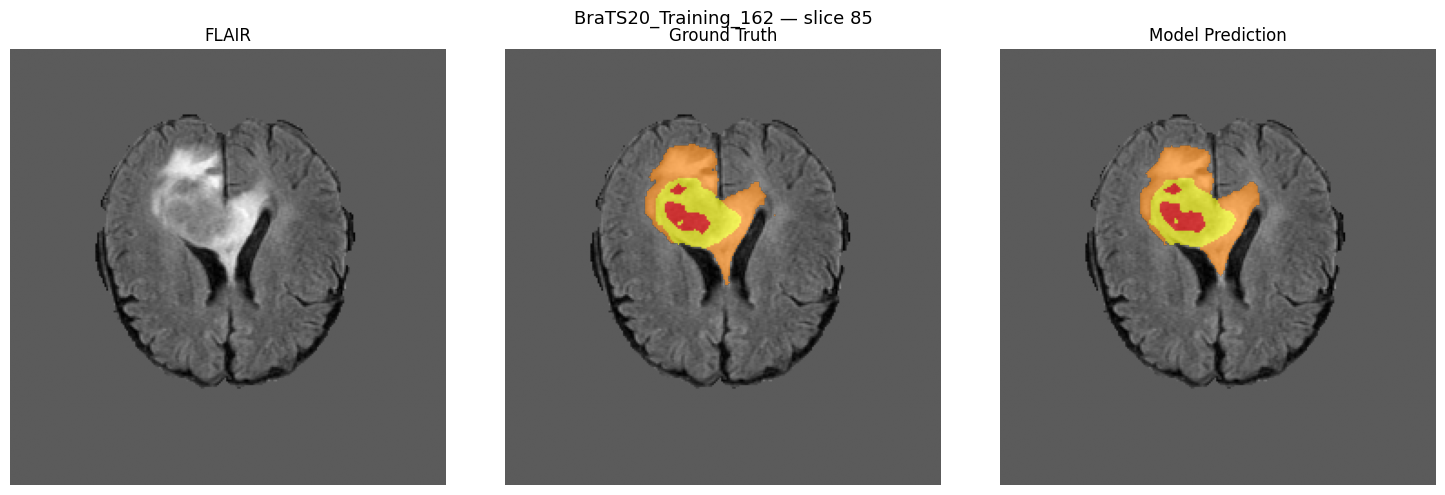

(array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],

In [29]:
# Best case visualization

best_sample = next(
    sample
    for sample in val_dicts
    if sample["patient_id"] == best_case["patient_id"]
)

visualize_patient(
    best_sample,
    filename="baseline_prediction_best_case.png"
)

Saved -> /content/drive/MyDrive/brain-tumor-segmentation/results/figures/baseline_prediction_typical_case.png


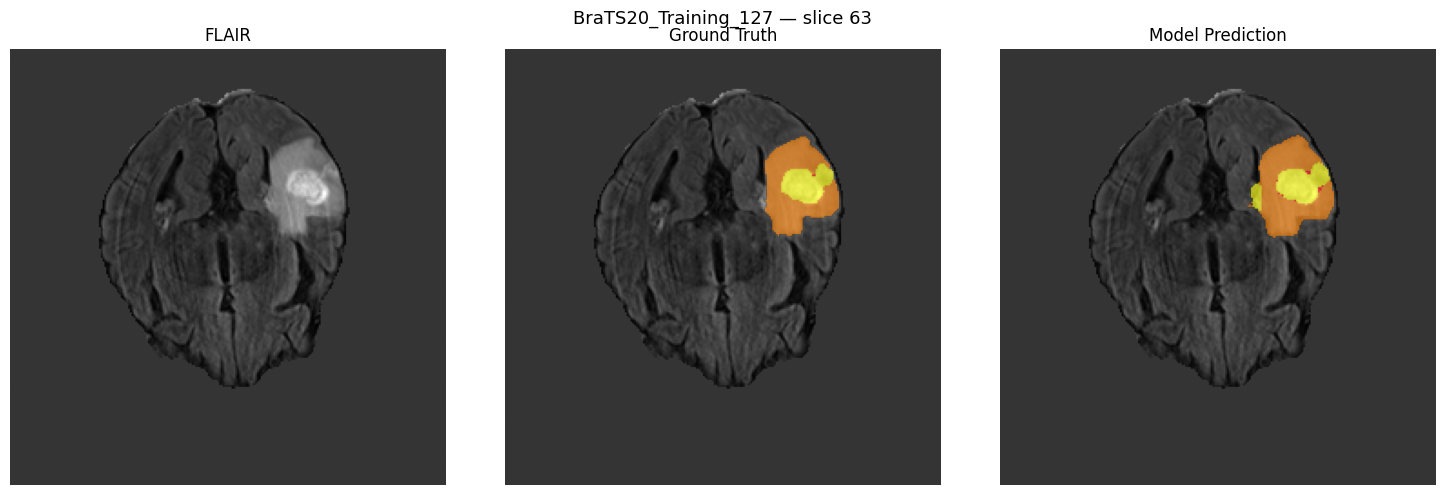

(array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],

In [30]:
# Typical case visualization

typical_sample = next(
    sample
    for sample in val_dicts
    if sample["patient_id"] == typical_case["patient_id"]
)

visualize_patient(
    typical_sample,
    filename="baseline_prediction_typical_case.png"
)

Saved -> /content/drive/MyDrive/brain-tumor-segmentation/results/figures/baseline_prediction_difficult_case.png


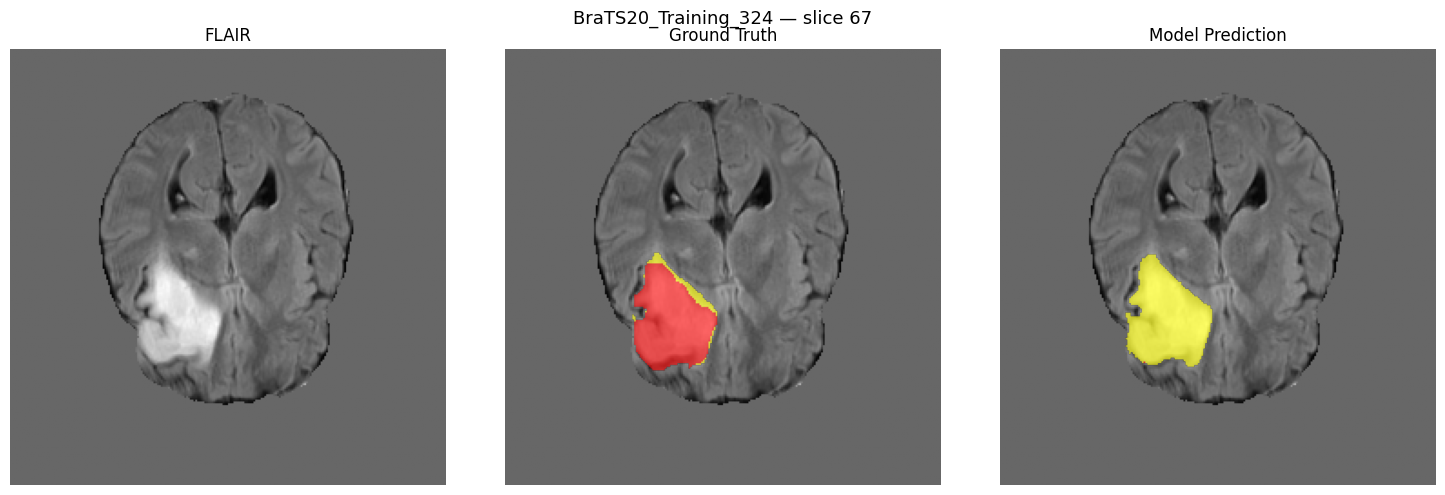

(array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],

In [31]:
# Difficult case visualization

difficult_sample = next(
    sample
    for sample in val_dicts
    if sample["patient_id"] == worst_case["patient_id"]
)

visualize_patient(
    difficult_sample,
    filename="baseline_prediction_difficult_case.png"
)

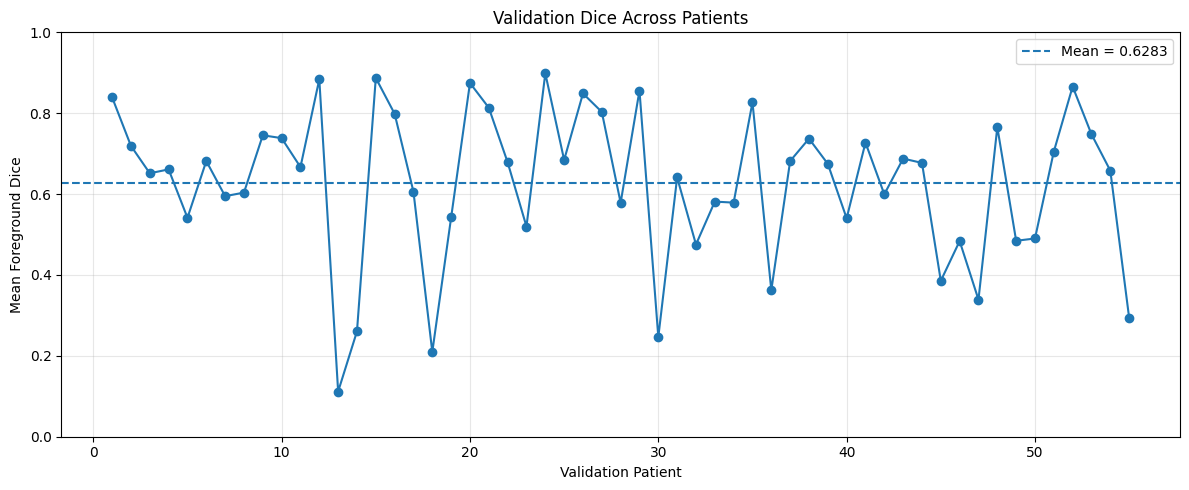

Saved -> /content/drive/MyDrive/brain-tumor-segmentation/results/figures/baseline_patient_dice.png


In [32]:
# Patient-level Dice plot

plt.figure(figsize=(12, 5))

plt.plot(
    range(1, len(patient_dice_df) + 1),
    patient_dice_df["mean_foreground_Dice"],
    marker="o"
)

plt.axhline(
    patient_scores.mean(),
    linestyle="--",
    label=f"Mean = {patient_scores.mean():.4f}"
)

plt.xlabel("Validation Patient")
plt.ylabel("Mean Foreground Dice")
plt.title("Validation Dice Across Patients")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

patient_plot_path = os.path.join(
    PATHS["figures"],
    "baseline_patient_dice.png"
)

plt.savefig(
    patient_plot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Saved -> {patient_plot_path}")

/tmp/ipykernel_1025/1434574912.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


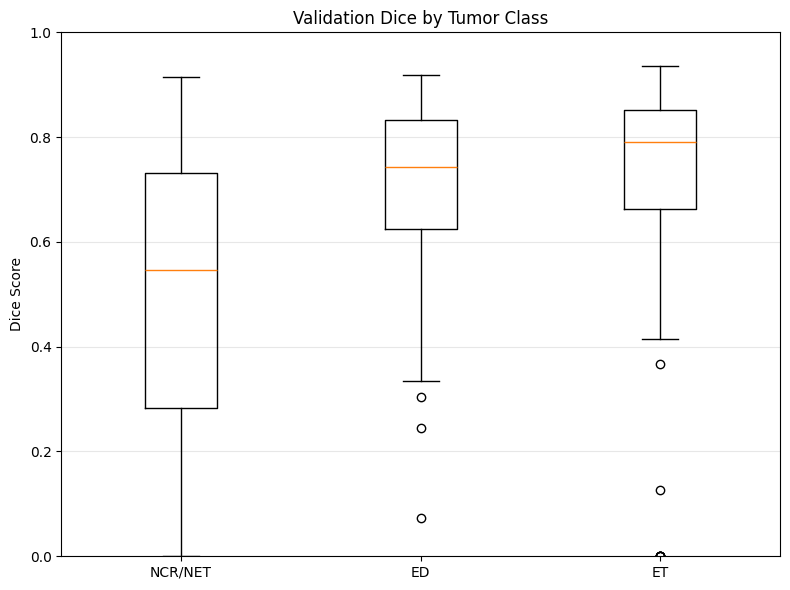

Saved -> /content/drive/MyDrive/brain-tumor-segmentation/results/figures/baseline_per_class_dice.png


In [33]:
# Per-class Dice plot

class_columns = [
    "NCR_NET_Dice",
    "ED_Dice",
    "ET_Dice"
]

class_labels = [
    "NCR/NET",
    "ED",
    "ET"
]

class_values = [
    patient_dice_df[col].dropna()
    for col in class_columns
]

plt.figure(figsize=(8, 6))

plt.boxplot(
    class_values,
    labels=class_labels
)

plt.ylabel("Dice Score")
plt.title("Validation Dice by Tumor Class")
plt.ylim(0, 1)
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

class_plot_path = os.path.join(
    PATHS["figures"],
    "baseline_per_class_dice.png"
)

plt.savefig(
    class_plot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Saved -> {class_plot_path}")

In [34]:
# Save patient-level results

patient_csv_path = os.path.join(
    PATHS["metrics"],
    "baseline_patient_dice.csv"
)

patient_dice_df.to_csv(
    patient_csv_path,
    index=False
)

print(f"Saved -> {patient_csv_path}")

Saved -> /content/drive/MyDrive/brain-tumor-segmentation/results/metrics/baseline_patient_dice.csv


In [35]:
# Final summary

print("=" * 70)
print("BASELINE 3D BRAIN TUMOR SEGMENTATION — FINAL EVALUATION")
print("=" * 70)

print(f"Model:             MONAI 3D U-Net")
print(f"Parameters:        {n_params:,}")
print(f"Validation cases:  {len(val_dicts)}")
print(f"Patch size:        {patch_size}")

print()
print(
    f"Training best Dice: "
    f"{0.6479:.4f}"
)

print(
    f"Full validation Dice: "
    f"{full_validation_dice:.4f}"
)

print()
print("Per-class Dice:")

print(
    f"  NCR/NET: "
    f"{per_class_values[0]:.4f}"
)

print(
    f"  ED:      "
    f"{per_class_values[1]:.4f}"
)

print(
    f"  ET:      "
    f"{per_class_values[2]:.4f}"
)

print()
print("Patient-level foreground Dice:")

print(
    f"  Mean:   {patient_scores.mean():.4f}"
)

print(
    f"  Std:    {patient_scores.std():.4f}"
)

print(
    f"  Median: {patient_scores.median():.4f}"
)

print(
    f"  Min:    {patient_scores.min():.4f}"
)

print(
    f"  Max:    {patient_scores.max():.4f}"
)

print("=" * 70)

BASELINE 3D BRAIN TUMOR SEGMENTATION — FINAL EVALUATION
Model:             MONAI 3D U-Net
Parameters:        4,811,129
Validation cases:  55
Patch size:        (96, 96, 96)

Training best Dice: 0.6479
Full validation Dice: 0.6479

Per-class Dice:
  NCR/NET: 0.5160
  ED:      0.6965
  ET:      0.7652

Patient-level foreground Dice:
  Mean:   0.6283
  Std:    0.1874
  Median: 0.6668
  Min:    0.1117
  Max:    0.8986
